In [1]:
import tensorflow as tf
import time
import glob

def process_path(file_path):
    # Read the file and decode it
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=1) # Medical MNIST is grayscale
    img = tf.image.convert_image_dtype(img, tf.float32) # Normalizes to [0, 1]
    img = tf.image.resize(img, [64, 64])
    
    # For Autoencoders, the input and target are the same image
    return img, img 

def get_dataset(global_batch_size):
    # Make sure this path matches the extracted Medical MNIST path in Kaggle
    file_pattern = '/kaggle/input/datasets/andrewmvd/medical-mnist/*/*.jpeg' 
    
    list_ds = tf.data.Dataset.list_files(file_pattern)
    
    ds = list_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(global_batch_size, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    
    return ds

2026-04-22 13:34:55.000637: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776864895.205543      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776864895.268339      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776864895.750181      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776864895.750241      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776864895.750245      55 computation_placer.cc:177] computation placer alr

In [2]:
LATENT_DIM = 64

# --- Autoencoder (AE) Architecture ---
def build_ae():
    # Encoder
    encoder_inputs = tf.keras.Input(shape=(64, 64, 1))
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = tf.keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = tf.keras.layers.Flatten()(x)
    latent = tf.keras.layers.Dense(LATENT_DIM, activation="relu")(x)
    encoder = tf.keras.Model(encoder_inputs, latent, name="ae_encoder")

    # Decoder
    latent_inputs = tf.keras.Input(shape=(LATENT_DIM,))
    x = tf.keras.layers.Dense(16 * 16 * 64, activation="relu")(latent_inputs)
    x = tf.keras.layers.Reshape((16, 16, 64))(x)
    x = tf.keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = tf.keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = tf.keras.layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="ae_decoder")

    return tf.keras.Model(encoder_inputs, decoder(encoder(encoder_inputs)), name="autoencoder")


# --- Variational Autoencoder (VAE) Architecture ---
class Sampling(tf.keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae_components():
    # VAE Encoder
    encoder_inputs = tf.keras.Input(shape=(64, 64, 1))
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = tf.keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = tf.keras.layers.Flatten()(x)
    z_mean = tf.keras.layers.Dense(LATENT_DIM, name="z_mean")(x)
    z_log_var = tf.keras.layers.Dense(LATENT_DIM, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")

    # VAE Decoder (Architecture identical to AE decoder)
    latent_inputs = tf.keras.Input(shape=(LATENT_DIM,))
    x = tf.keras.layers.Dense(16 * 16 * 64, activation="relu")(latent_inputs)
    x = tf.keras.layers.Reshape((16, 16, 64))(x)
    x = tf.keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = tf.keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = tf.keras.layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="vae_decoder")
    
    return encoder, decoder

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    # --- ADD THIS CALL METHOD ---
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        # Unpack the tf.data tuple (inputs, targets)
        if isinstance(data, tuple):
            data = data[0] 
            
        with tf.GradientTape() as tape:
            # We can now use self.call() or just call the components
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            # Reconstruction loss (Binary Crossentropy)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            
            # KL Divergence loss
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [4]:
def run_training(strategy, model_type="AE", epochs=5):
    # 1. Clear the Keras backend session BEFORE defining the strategy scope
    tf.keras.backend.clear_session()
    
    BATCH_SIZE_PER_REPLICA = 64
    global_batch_size = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync
    
    print(f"\n--- Training {model_type} using {strategy.__class__.__name__} ---")
    dataset = get_dataset(global_batch_size)

    # 2. Everything—from building the layers to compiling—must be inside this scope
    with strategy.scope():
        if model_type == "AE":
            model = build_ae() 
            model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        elif model_type == "VAE":
            encoder, decoder = build_vae_components()
            model = VAE(encoder, decoder)
            model.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

    start_time = time.time()
    # verbose=1 is good for tracking, but set to 2 if you want cleaner logs
    history = model.fit(dataset, epochs=epochs, verbose=1) 
    end_time = time.time()
    
    return history, (end_time - start_time), model

# Define Strategies
multi_gpu_strategy = tf.distribute.MirroredStrategy() 
single_gpu_strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")

# Run Comparison for Autoencoder
ae_single_gpu_history, ae_single_time, ae_single_model = run_training(single_gpu_strategy, "AE", epochs=2)
ae_multi_gpu_history, ae_multi_time, ae_multi_model = run_training(multi_gpu_strategy, "AE", epochs=2)

# Run Comparison for Variational Autoencoder
vae_single_gpu_history, vae_single_time, vae_single_model = run_training(single_gpu_strategy, "VAE", epochs=2)
vae_multi_gpu_history, vae_multi_time, vae_multi_model = run_training(multi_gpu_strategy, "VAE", epochs=2)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')

--- Training AE using OneDeviceStrategy ---
Epoch 1/2
921/921 ━━━━━━━━━━━━━━━━━━━━ 121s 131ms/step - loss: 0.0254
Epoch 2/2
921/921 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - loss: 0.0070

--- Training AE using MirroredStrategy ---
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/2
INFO:tensorflow:Collective all_reduce tensors: 14 all_

I0000 00:00:1776865115.620275     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0337INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
460/460 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - loss: 0.0336
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 2/2
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0084INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task

--- Performance and Time Comparison ---


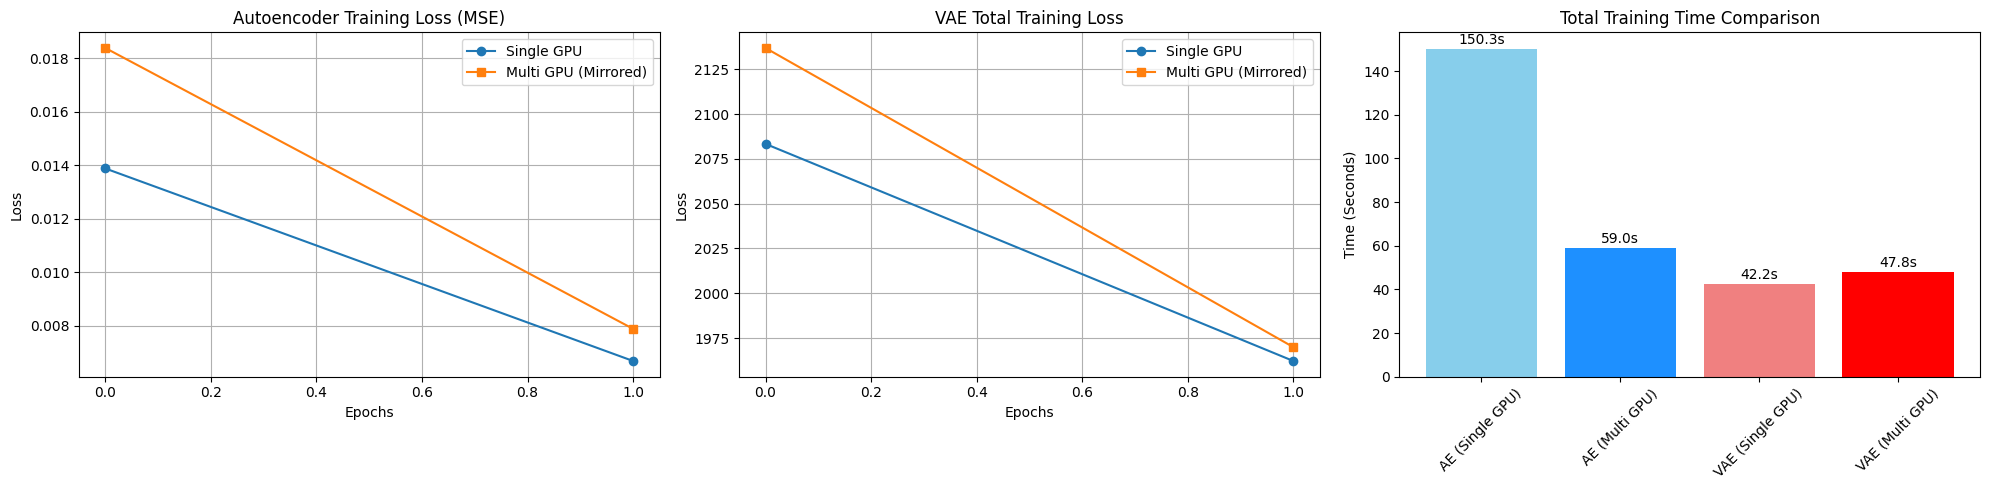


--- Output Reconstructions Comparison ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


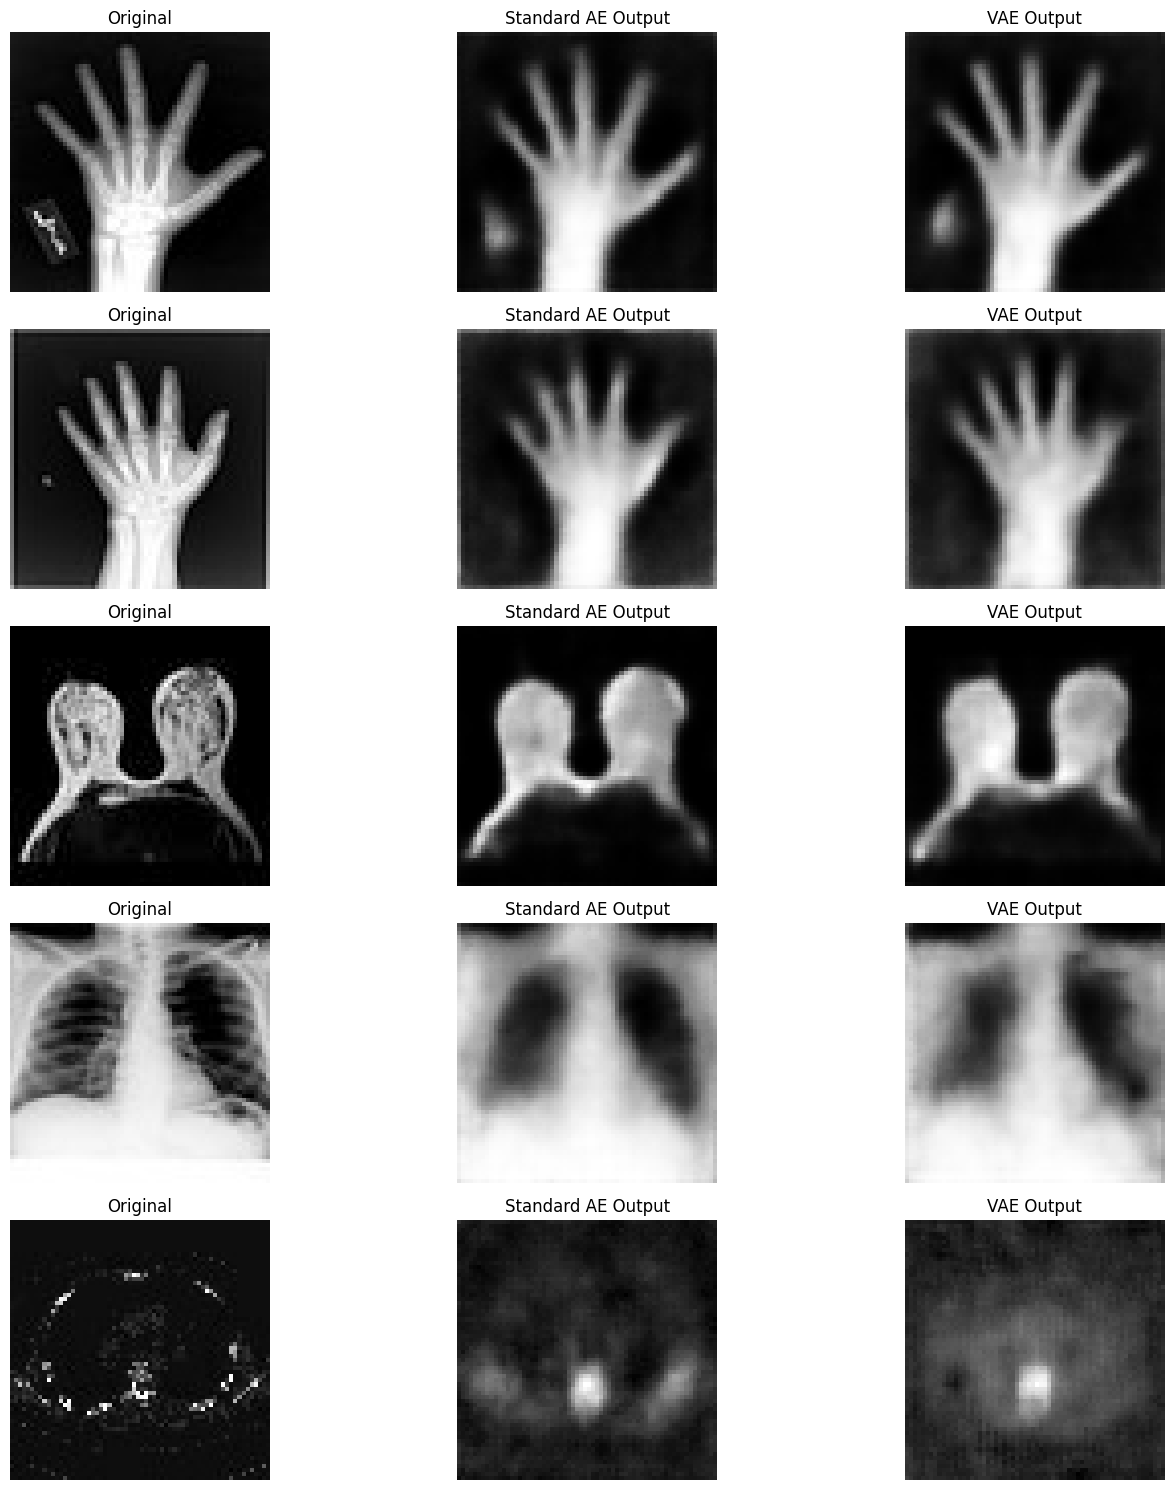

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_performance_metrics():
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Autoencoder Loss Comparison
    axes[0].plot(ae_single_gpu_history.history['loss'], label='Single GPU', marker='o')
    axes[0].plot(ae_multi_gpu_history.history['loss'], label='Multi GPU (Mirrored)', marker='s')
    axes[0].set_title('Autoencoder Training Loss (MSE)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # 2. VAE Loss Comparison
    axes[1].plot(vae_single_gpu_history.history['loss'], label='Single GPU', marker='o')
    axes[1].plot(vae_multi_gpu_history.history['loss'], label='Multi GPU (Mirrored)', marker='s')
    axes[1].set_title('VAE Total Training Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    # 3. Training Time Comparison
    labels = ['AE (Single GPU)', 'AE (Multi GPU)', 'VAE (Single GPU)', 'VAE (Multi GPU)']
    times = [ae_single_time, ae_multi_time, vae_single_time, vae_multi_time]
    colors = ['skyblue', 'dodgerblue', 'lightcoral', 'red']
    
    axes[2].bar(labels, times, color=colors)
    axes[2].set_title('Total Training Time Comparison')
    axes[2].set_ylabel('Time (Seconds)')
    axes[2].tick_params(axis='x', rotation=45)
    
    # Add text labels on top of the bars
    for i, v in enumerate(times):
        axes[2].text(i, v + 1, f"{v:.1f}s", ha='center', va='bottom')
        
    plt.tight_layout()
    plt.show()

def plot_model_outputs(dataset, ae_model, vae_model, num_images=5):
    # Take one batch from the dataset
    for images in dataset.take(1):
        if isinstance(images, tuple):
            images = images[0]
            
        # Get predictions
        ae_reconstructions = ae_model.predict(images[:num_images])
        vae_reconstructions = vae_model.predict(images[:num_images])
        
        plt.figure(figsize=(15, num_images * 3))
        
        for i in range(num_images):
            # Original Image
            ax = plt.subplot(num_images, 3, i * 3 + 1)
            plt.imshow(tf.squeeze(images[i]), cmap="gray")
            plt.title("Original")
            plt.axis("off")
            
            # Autoencoder Reconstruction
            ax = plt.subplot(num_images, 3, i * 3 + 2)
            plt.imshow(tf.squeeze(ae_reconstructions[i]), cmap="gray")
            plt.title("Standard AE Output")
            plt.axis("off")
            
            # VAE Reconstruction
            ax = plt.subplot(num_images, 3, i * 3 + 3)
            plt.imshow(tf.squeeze(vae_reconstructions[i]), cmap="gray")
            plt.title("VAE Output")
            plt.axis("off")
            
        plt.tight_layout()
        plt.show()

# Run the plotting functions
print("--- Performance and Time Comparison ---")
plot_performance_metrics()n

print("\n--- Output Reconstructions Comparison ---")
# Using the multi-gpu trained models for the output comparison
# We get a single dataset iterator for visualization (using a small batch size for inference)
test_dataset = get_dataset(global_batch_size=16) 
plot_model_outputs(test_dataset, ae_multi_model, vae_multi_model, num_images=5)